In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

In [2]:
#ticker = 'NVDA'
#ticker = 'GOOG'
#ticker = 'AMZN'
ticker = 'META'

In [17]:
# Import the stock data
data = yf.download(ticker, start='2023-01-01', end='2026-04-07')
print("Number of rows of data imported: {}".format(data.shape[0]))
data['Returns'] = data['Close'].pct_change() # Calculate % change for each day

C:\Users\neilj\AppData\Local\Temp\ipykernel_2348\2134333103.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2023-01-01', end='2026-04-07')
[*********************100%***********************]  1 of 1 completed

Number of rows of data imported: 816


In [7]:
# Check how it looks
data.head()

Price,Close,High,Low,Open,Volume,Returns
Ticker,META,META,META,META,META,
Date,,,,,,
2023-01-03,123.768730,125.386043,121.327885,121.863682,35528500,NaN
2023-01-04,126.378258,128.045177,124.870089,126.388174,32397100,0.021084
2023-01-05,125.951614,127.519314,123.570300,125.147916,25447100,-0.003376
2023-01-06,129.007599,129.315183,125.058586,127.965772,27584500,0.024263
2023-01-09,128.461914,131.914814,128.273391,130.138758,26649100,-0.004230


In [24]:
# Set some parameters for your simulation
num_simulations = 10000
num_days = 25
last_price = data['Close'].iloc[-1,0]
simulation_df = np.zeros((num_days, num_simulations))
mu = data['Returns'].mean()
sigma = data['Returns'].std()

In [25]:
# Run the Monte Carlo simulation
for simulation in range(num_simulations):
    price_list = [last_price]

    for d in range(num_days):
        price = price_list[-1] * np.exp((mu - 0.5 * sigma**2) + sigma * np.random.normal())
        price_list.append(price)
    simulation_df[:, simulation] = price_list[1:]

final_prices = simulation_df[-1:]
median_final_price = np.median(final_prices)
most_likely_simulation_index = np.argmin(np.abs(final_prices - median_final_price))
most_likely_simulation = simulation_df[:, most_likely_simulation_index]

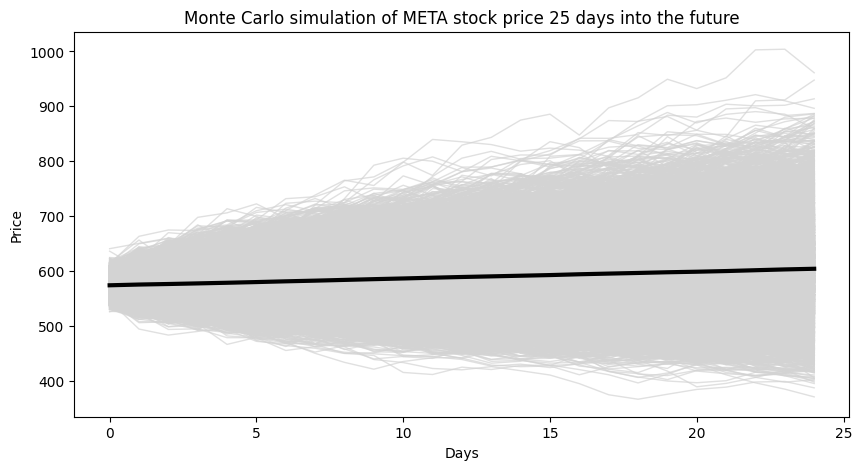

The most likely stock price for META in 25 days time is 599.9509155303462


In [27]:
# Plot the Monte Carlo output
# Results of each individual simulation are shown in grey, the thick black line is the mean
plt.figure(figsize=(10,5))
plt.plot(simulation_df, color='lightgray', alpha=0.7, linewidth=1)
mean_path = simulation_df.mean(axis=1)
plt.plot(mean_path, color='black', linewidth=3, label='Mean Path')
plt.title('Monte Carlo simulation of {} stock price {} days into the future'.format(ticker, num_days)) 
plt.xlabel('Days')
plt.ylabel('Price')
plt.show()
print("The most likely stock price for {} in {} days time is {}".format(ticker, num_days, most_likely_simulation[-1]))